# Resultados - Reunião de 11/03/25


Neste notebook, analise o efeito de aplicar calibração na simulação. Comparo a simulação com calibração com 3 cenários:

1. Simulação utilizando BPR
2. Simulação recomendado itens aleatorios
3. Simulação recomendando item mais popular.


## Mudanças em relação ao último encontro

* Notei que eu não estava removendo itens previamente interagidos ao realizar recomendações. Isso estava gerando um certo ruído nas recomendações (Algo que pode ser visto para a simulação que enviei por anexo no email)
* Inclusão de calibração na simulação


## Próximos passos

* Rodar experimento de calibração por algumas iterações a mais (Consigo rodar uma simulaç~ao com 4000 rodadas em 8h)
* Medir divergência de itens recomendados, ao invés de itens interagidos pelo usuário: enquanto que nessa análise estou observando se a recomendação altera o que o usuário escolhe ao longo do tempo, na análise de recomendação observo se **o recomendador, no loop de feedback, passa a recomendar itens cada vez mais diferentes em relação ao que o usuário mostrou preferência no início**.

In [1]:
from dynamicTasteDistortion.scripts.vis import plot_metric_comparison
from dynamicTasteDistortion.scripts.vis import plot_metrics_smoothed

### Experiments

In [29]:
calibrated = "experiments/steck_calibration/bpr_classic_calibrated.yaml"
random_rec = "experiments/random_rec_with_oracle_experiment.yaml"
most_popular = "experiments/most_popular_with_oracle_experiment.yaml"
bpr = "experiments/bpr_classic_uncalibrated.yaml"

## Comparação: calibrado x não calibrado


Neste experimento, utilizo a calibração clássica de Steck no Movielens-1m ao longo de 500 iterações, retreinando o modelo a cada 5 iterações, para uma amostra de 1000 usuários.

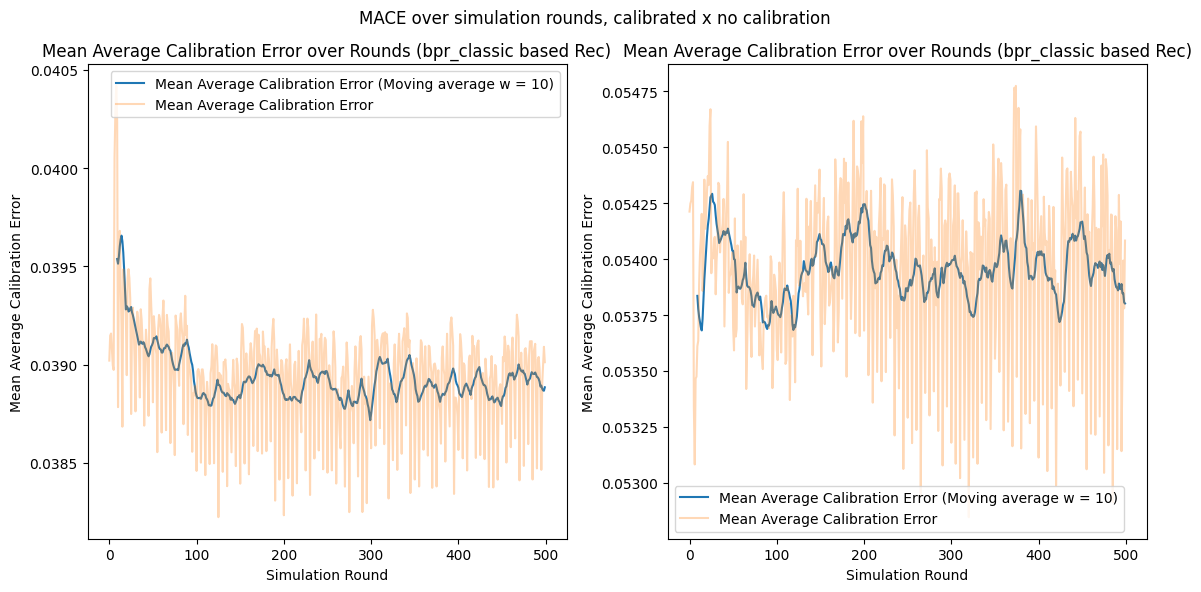

In [31]:
plot_metric_comparison(calibrated, bpr, metric_name="mace", title="MACE over simulation rounds, calibrated x no calibration", graph="line", plot_retrain_points=False,  window_size=10)

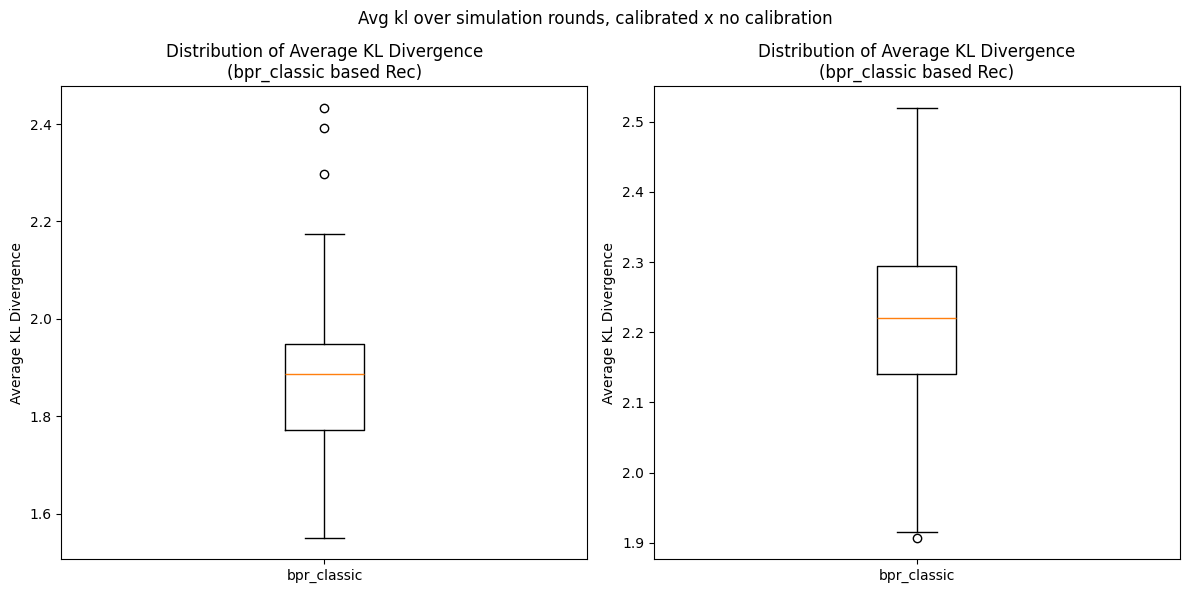

In [9]:
plot_metric_comparison(calibrated, bpr, metric_name="kl", title="Avg kl over simulation rounds, calibrated x no calibration", graph="box", plot_retrain_points=False,  window_size=10)

Na esquerda, a simulação com calibração. A direita, a simulação sem calibração. Podemos notar, imediatamente, como os valores de MACE são menores para a versão calibrada do que para a versão não calibrada, o que é esperado. Além disso, a versão calibrada parece se corrigir até atingir um patamar de 0.0390 quando se estabiliza. Analisando o boxplot acima, as métricas aparentemente oscilam de maneira similar, tendo em vista a distância interquartil similar entre os dois ambientes de simulação.


Se analisarmos a divergência KL - mais sensível a flutuações do que MACE - Notamos outro ponto interessante: **a simulação sem calibração apresenta uma divergência cada vez maior em relação às preferÊncias iniciais, enquanto que a versão calibrada se mantém estável ao longo do tempo**.


(Obs: Essa curva ascendente de divergência KL parece contraditória tendo em vista que o MACE é relativamente estável para a recomendação não calibrada. Então isso pode ser um erro de implementação da divergência média, ou nesse caso temos fatores que não afetam o mace, como o rankeamento das recomendações)

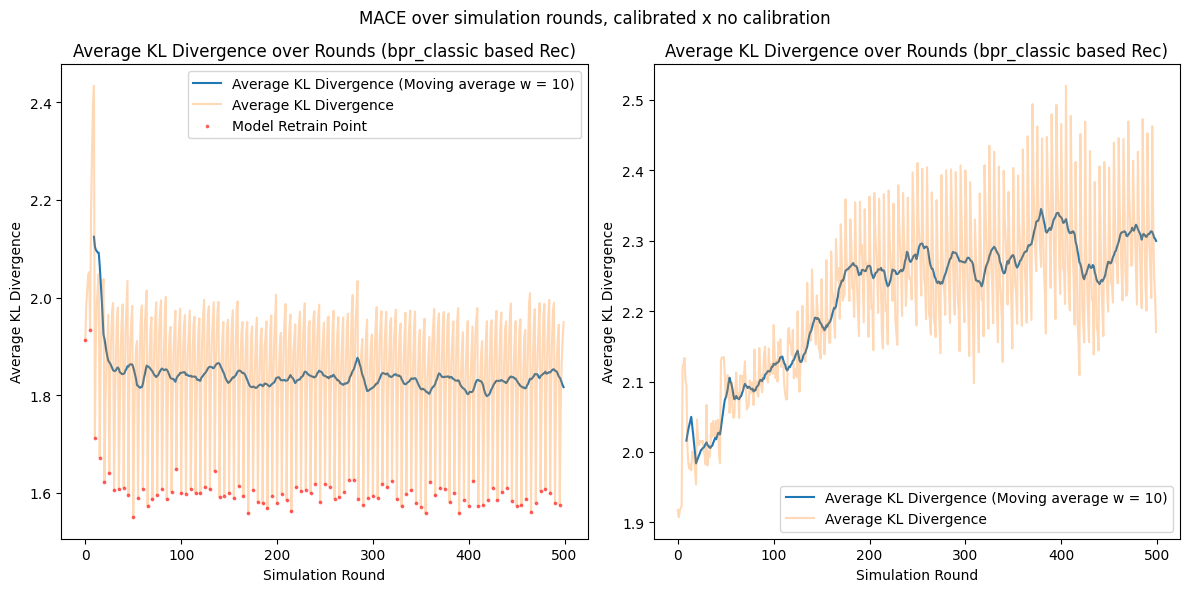

In [7]:
plot_metric_comparison(calibrated, bpr, metric_name="kl", title="MACE over simulation rounds, calibrated x no calibration", graph="line", plot_retrain_points=True,  window_size=10)

## Comparação com recomendação aleatória e most popular

Finalmente, comparamos a recomendação BPR calibrada com baselines não personalizados (Recomendação aleatória e most-popular). Todos experimetnos foram executados por 500 rodadas. Nota-se que, como esperado, o MACE do modelo calibrado é muito menor que ambos os casos.

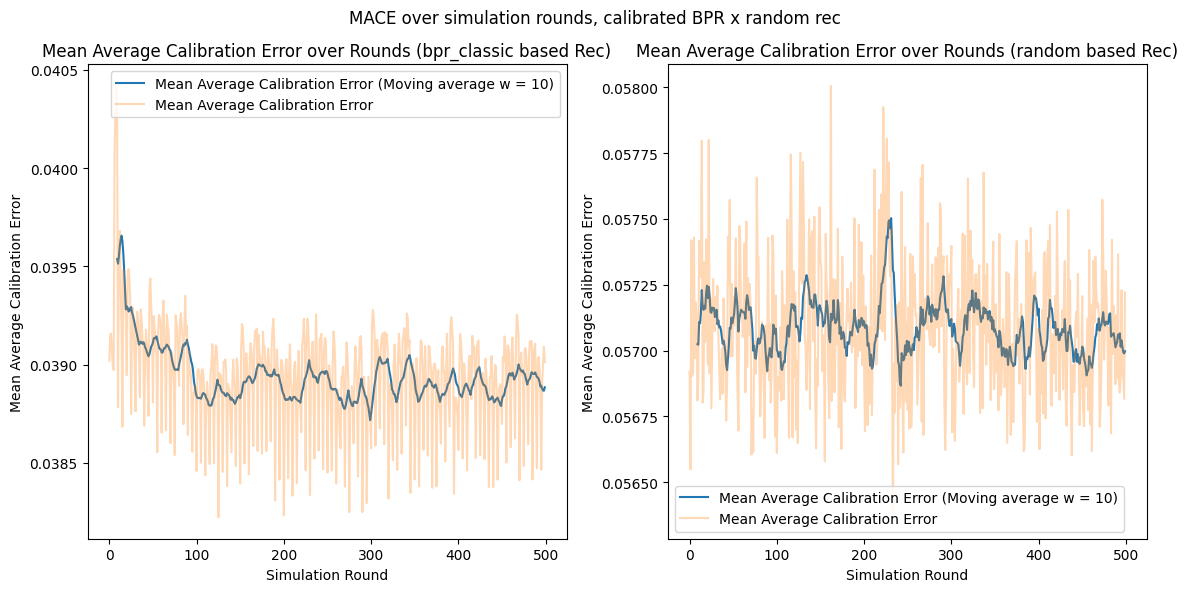

In [14]:
plot_metric_comparison(calibrated, random_rec, metric_name="mace", title="MACE over simulation rounds, calibrated BPR x random rec", graph="line", plot_retrain_points=False,  window_size=10)

Aqui, most popular tende a recomendar os mesmos itens (tirando aqueles que o usuário já interagiu), então há baixa oscilação, mas a distorção de preferência é maior do que o algoritmo calibrado.

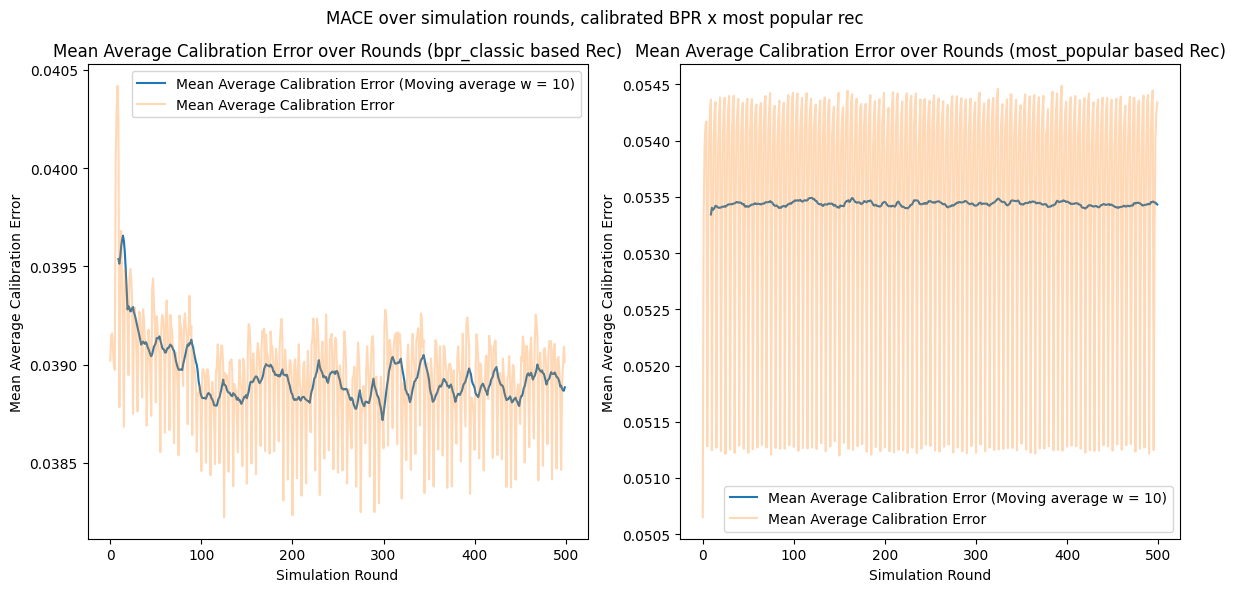

In [26]:
plot_metric_comparison(calibrated, most_popular, metric_name="mace", title="MACE over simulation rounds, calibrated BPR x most popular rec", graph="line", plot_retrain_points=False,  window_size=10)

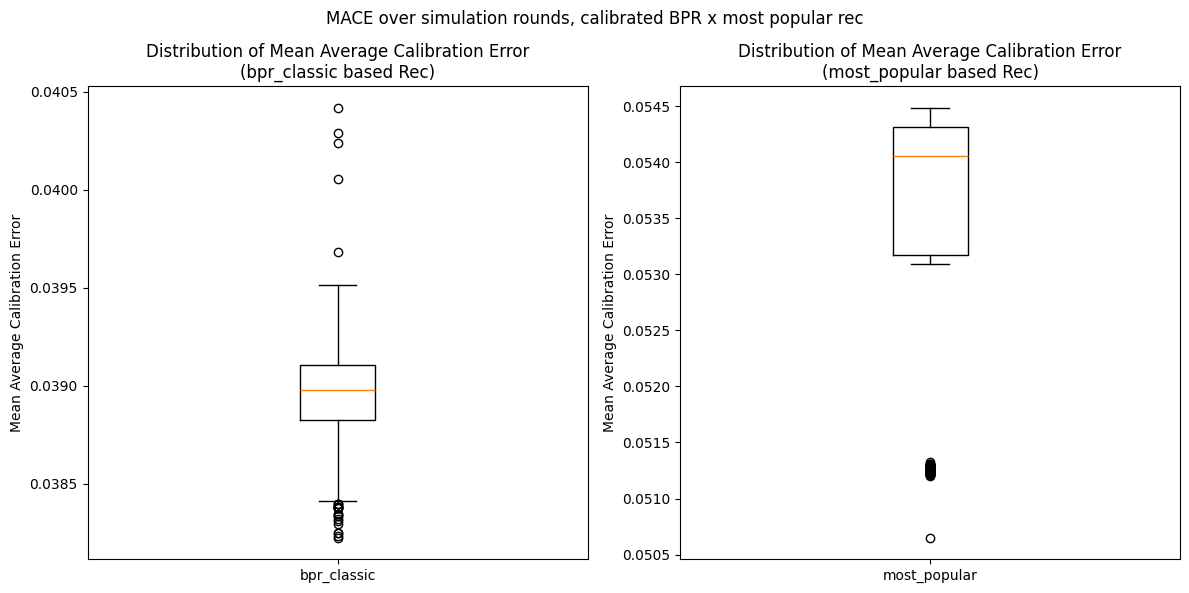

In [23]:
plot_metric_comparison(calibrated, most_popular, metric_name="mace", title="MACE over simulation rounds, calibrated BPR x most popular rec", graph="box", plot_retrain_points=False,  window_size=10)

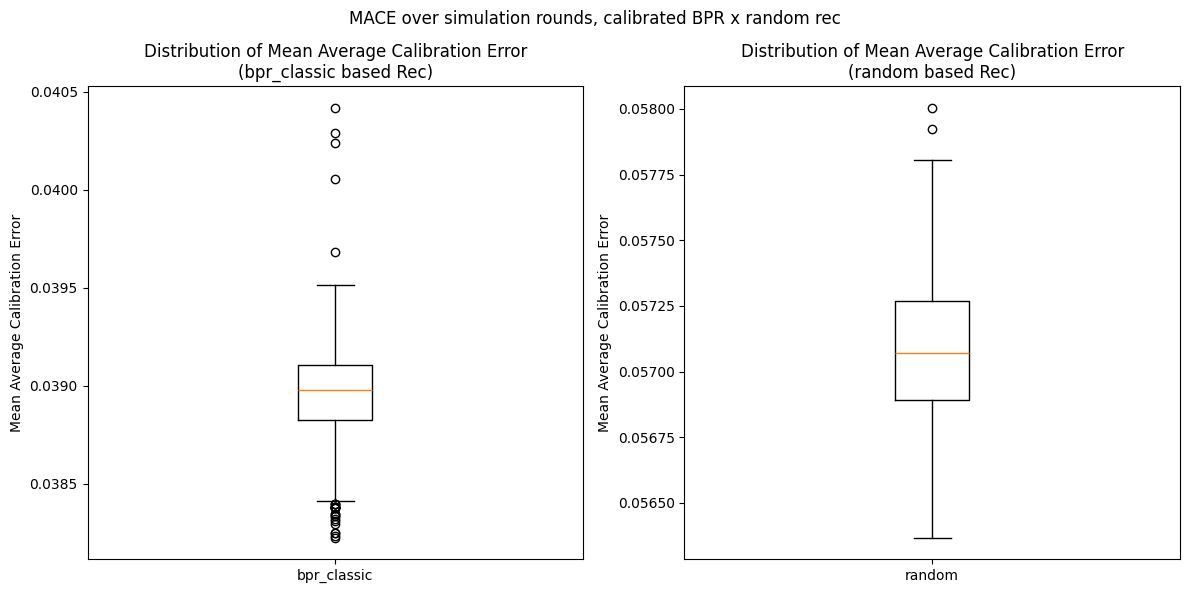

In [28]:
plot_metric_comparison(calibrated, random_rec, metric_name="mace", title="MACE over simulation rounds, calibrated BPR x random rec", graph="box", plot_retrain_points=False,  window_size=10)

## Calibração para mais iterações

In [35]:
calibrated_longer = "experiments/steck_calibration/bpr_classic_calibrated_large.yaml"

In [36]:
from dynamicTasteDistortion.ioUtils import read_experiment, read_metrics
calibrated_longer_exp = read_experiment(calibrated_longer)
mace, kl = read_metrics(calibrated_longer_exp)

In [37]:
from dynamicTasteDistortion.scripts.vis import plot_metrics_smoothed

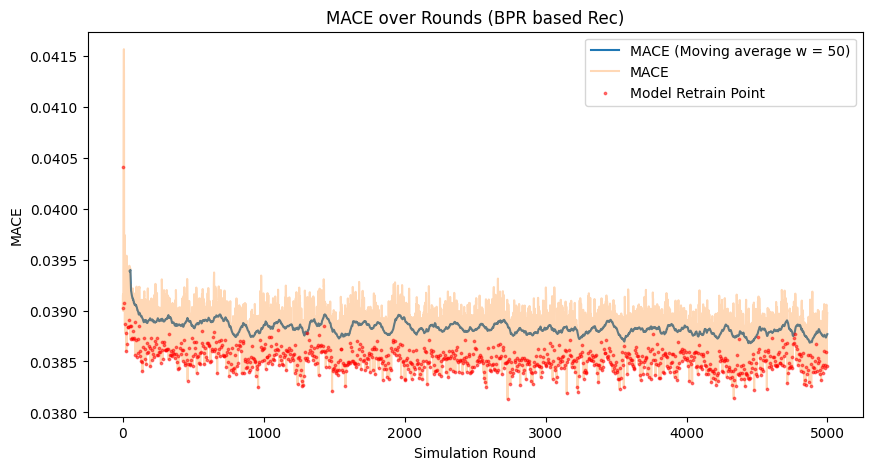

In [39]:
plot_metrics_smoothed(ax=None, metric=mace, model_name="BPR", metric_name="MACE", step=calibrated_longer_exp["num_rounds_per_eval"], window_size=50)